# Kimi K3 Direct — P0 to P12 validation extraction

This notebook runs the full prompt progression, **P0 through P12**, on all dialogues in the annotated validation set using Moonshot's first-party Kimi K3 API. It then scores every prompt with the shared repository scorer.

The model configuration is held constant across prompts: Kimi K3, maximum reasoning effort, and Moonshot's server-controlled sampling. Kimi K3 fixes temperature and top-p server-side, so the notebook does not send a temperature parameter.

Cache records are stored under:

```text
extension/artifacts/extraction_cache/validation/
  moonshot-direct__kimi-k3-max/{prompt}/{dialogue_id}.json
```

The validation experiment has its own cache namespace. Valid cache records are reused; missing or invalid records are requested again when extraction is enabled. The selected production prompt, P11, is separately promoted to the `train` namespace so a later full-training-data extraction can reuse those records.

In [11]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

_here = Path.cwd()
for _candidate in [_here, *_here.parents]:
    if (_candidate / 'extension' / 'artifacts').exists():
        os.chdir(_candidate)
        break
else:
    raise FileNotFoundError('Run this notebook from inside the repository.')
sys.path.insert(0, str(Path.cwd()))

from extension.scripts.data_management.load_annotation_data import load_dataset
from extension.scripts.annotation import extraction, moonshot_kimi, prompt_loader, scoring

try:
    moonshot_kimi._api_key()
    KEY_FOUND = True
except RuntimeError:
    KEY_FOUND = False

print('repository:', Path.cwd())
print('MOONSHOT_API_KEY found:', KEY_FOUND)

repository: /Users/tandon.utsav2/Desktop/Experiment_1
MOONSHOT_API_KEY found: True


## 1. Load the validation set

Only the dialogue text and ordered unit names are passed to the model. Gold P/A/N labels and adjudication fields remain available to the scorer but are not included in the prompt.

In [12]:
VALIDATION_PATH = Path(
    'extension/artifacts/annotation_dev_val_and_eval_sets/validation_set.csv'
)
CACHE_SPLIT = 'validation'

gold = load_dataset(VALIDATION_PATH)
DIALOGUES = extraction.dialogues_from(gold, split=CACHE_SPLIT)
DIALOGUE_IDS = [dialogue['dialogue_id'] for dialogue in DIALOGUES]

assert len(DIALOGUE_IDS) == len(set(DIALOGUE_IDS))
print(f'{len(DIALOGUES)} validation dialogues, {len(gold)} scored units')
print('dialogue IDs:', DIALOGUE_IDS)

78 validation dialogues, 544 scored units
dialogue IDs: [1, 21, 35, 79, 143, 178, 255, 270, 275, 289, 300, 306, 323, 344, 351, 356, 380, 434, 448, 494, 532, 554, 589, 617, 635, 656, 695, 736, 758, 779, 818, 822, 842, 862, 947, 958, 966, 980, 992, 1026, 1051, 1063, 1071, 1084, 1089, 1107, 1119, 1217, 1221, 1300, 1349, 1421, 1452, 1490, 1519, 1540, 1553, 1555, 1557, 1571, 1615, 1658, 1668, 1717, 1719, 1776, 1780, 1870, 1890, 1916, 1941, 2018, 2164, 2192, 2196, 2202, 2206, 2222]


## 2. Experiment configuration

Set `RUN_EXTRACTION=False` to inspect and score existing cache records without making API requests. With extraction enabled, the backend immediately reuses valid records and requests only missing or invalid ones.

In [13]:
PROMPTS = [f'P{index}' for index in range(13)]
EFFORT = 'max'
MAX_WORKERS = 20
RUN_EXTRACTION = True
N_BOOTSTRAP = 0

available_prompts = set(prompt_loader.list_prompts())
missing_prompts = [prompt for prompt in PROMPTS if prompt not in available_prompts]
assert not missing_prompts, f'Missing prompt files: {missing_prompts}'

SLUG = moonshot_kimi.cache_slug(EFFORT)
print('model:', SLUG)
print('prompts:', PROMPTS)
print('dialogues per prompt:', len(DIALOGUES))
print('maximum concurrent workers:', MAX_WORKERS)
print('extraction enabled:', RUN_EXTRACTION)

model: moonshot-direct/kimi-k3-max
prompts: ['P0', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11', 'P12']
dialogues per prompt: 78
maximum concurrent workers: 20
extraction enabled: True


## 3. Run extraction and inspect cache coverage

The backend prints dialogue completion statuses while each prompt is running. Afterward, this section produces one compact row per prompt showing valid, invalid, missing and unreadable records. Invalid records remain visible and will be retried the next time extraction is enabled.

In [14]:
def cache_path_for(prompt, dialogue):
    return extraction.cache_path(
        SLUG, prompt, dialogue['dialogue_id'], dialogue['split']
    )


def cache_summary(prompt):
    valid_ids, invalid_ids, missing_ids, unreadable_ids = [], [], [], []
    completion_tokens, latencies = [], []

    for dialogue in DIALOGUES:
        path = cache_path_for(prompt, dialogue)
        if not path.is_file():
            missing_ids.append(dialogue['dialogue_id'])
            continue
        try:
            with path.open() as handle:
                record = json.load(handle)
        except (OSError, json.JSONDecodeError):
            unreadable_ids.append(dialogue['dialogue_id'])
            continue

        target = valid_ids if record.get('valid') else invalid_ids
        target.append(dialogue['dialogue_id'])
        latencies.append(record.get('latency_s', 0.0))
        attempts = record.get('attempts') or []
        if attempts:
            usage = (attempts[0].get('meta') or {}).get('usage') or {}
            tokens = usage.get('completion_tokens')
            if tokens is not None:
                completion_tokens.append(tokens)

    return {
        'prompt': prompt,
        'expected': len(DIALOGUES),
        'valid': len(valid_ids),
        'invalid': len(invalid_ids),
        'missing': len(missing_ids),
        'unreadable': len(unreadable_ids),
        'valid_rate': len(valid_ids) / len(DIALOGUES),
        'mean_completion_tokens': (
            sum(completion_tokens) / len(completion_tokens)
            if completion_tokens else float('nan')
        ),
        'mean_latency_s': (
            sum(latencies) / len(latencies)
            if latencies else float('nan')
        ),
        'invalid_ids': invalid_ids,
        'missing_ids': missing_ids,
        'unreadable_ids': unreadable_ids,
    }


if RUN_EXTRACTION and not KEY_FOUND:
    raise RuntimeError('Set MOONSHOT_API_KEY before running extraction.')

cache_rows = []
for prompt in PROMPTS:
    print(f'\n=== {prompt} ===')
    if RUN_EXTRACTION:
        moonshot_kimi.generate_annotations(
            prompt,
            DIALOGUES,
            reasoning_effort=EFFORT,
            max_workers=MAX_WORKERS,
        )
    row = cache_summary(prompt)
    cache_rows.append(row)
    print(
        f"{prompt}: {row['valid']}/{row['expected']} valid, "
        f"{row['invalid']} invalid, {row['missing']} missing, "
        f"{row['unreadable']} unreadable"
    )

cache_status = pd.DataFrame(cache_rows).set_index('prompt')
coverage_columns = [
    'expected', 'valid', 'invalid', 'missing', 'unreadable',
    'valid_rate', 'mean_completion_tokens', 'mean_latency_s',
]
display(cache_status[coverage_columns].round(3))

issue_columns = ['invalid_ids', 'missing_ids', 'unreadable_ids']
has_issues = cache_status[issue_columns].map(bool).any(axis=1)
if has_issues.any():
    print('Prompts requiring additional or corrected cache records')
    display(cache_status.loc[has_issues, issue_columns])


=== P0 ===
  306: cached
  300: cached
  380: cached
  323: cached
  554: cached
  494: cached
  255: cached
  79: cached
  275: cached
  448: cached
  143: cached
  35: cached
  434: cached
  356: cached
  289: cached
  21: cached
  617: cached
  656: cached
  351: cached
  270: cached
  178: cached
  736: cached
  1: cached
  589: cached
  532: cached
  344: cached
  758: cached
  779: cached
  635: cached
  695: cached
  862: cached
  958: cached
  947: cached
  822: cached
  818: cached
  992: cached
  1063: cached
  1221: cached
  1089: cached
  966: cached
  1119: cached
  980: cached
  1084: cached
  1051: cached
  1026: cached
  1349: cached
  842: cached
  1421: cached
  1107: cached
  1452: cached
  1490: cached
  1540: cached
  1668: cached
  1300: cached
  1071: cached
  1571: cached
  1217: cached
  1557: cached
  1519: cached
  1780: cached
  1916: cached
  1615: cached
  2196: cached
  1553: cached
  1890: cached
  1717: cached
  1719: cached
  1870: cached
  2202: cach

,expected,valid,invalid,missing,unreadable,valid_rate,mean_completion_tokens,mean_latency_s
prompt,,,,,,,,
P0,78,78,0,0,0,1.0,16248.295,518.231
P1,78,78,0,0,0,1.0,15958.846,549.635
P2,78,78,0,0,0,1.0,17050.282,559.357
P3,78,78,0,0,0,1.0,15357.308,430.474
P4,78,78,0,0,0,1.0,15813.897,421.763
P5,78,78,0,0,0,1.0,17104.449,664.204
P6,78,78,0,0,0,1.0,21483.308,644.783
P7,78,78,0,0,0,1.0,30734.308,723.611
P8,78,78,0,0,0,1.0,30336.590,684.786


## 4. Score every prompt

All agreement metrics are calculated only from valid cache records. `valid_rate` retains all requested dialogues in its denominator, so it must be interpreted alongside F1, accuracy, alpha and kappa. Bootstrap confidence intervals are disabled by default for this prompt comparison.

In [15]:
score_rows = []
for prompt in PROMPTS:
    metrics = scoring.score_config(
        gold=gold,
        model_slug=SLUG,
        prompt_name=prompt,
        dids=DIALOGUE_IDS,
        n_boot=N_BOOTSTRAP,
        split=CACHE_SPLIT,
    )
    score_rows.append(metrics)

scores = pd.DataFrame(score_rows).set_index('prompt').loc[PROMPTS]
print(f'Scored {len(scores)} prompts.')

Scored 13 prompts.


## 5. Overall five-family results

Macro, micro and weighted F1 treat `P` as the positive class. Accuracy, Krippendorff's alpha and Cohen's kappa use the full P/A/N labels. Cohen's kappa is reported overall across all valid family-turn cells. **Prompt words** counts whitespace-delimited words in the fully assembled static prompt and codebook, excluding dialogue-specific text.

In [16]:
overall_columns = [
    'prompt_word_count', 'valid_rate',
    'macro_f1_P', 'micro_f1_P', 'weighted_f1_P',
    'accuracy', 'alpha', 'kappa', 'latency_s',
]
overall_results = scores[overall_columns].rename(columns={
    'prompt_word_count': 'prompt words',
    'valid_rate': 'valid rate',
    'macro_f1_P': 'macro F1 (P)',
    'micro_f1_P': 'micro F1 (P)',
    'weighted_f1_P': 'weighted F1 (P)',
    'latency_s': 'mean latency (s)',
})
display(overall_results.round(3))

,prompt words,valid rate,macro F1 (P),micro F1 (P),weighted F1 (P),accuracy,alpha,kappa,mean latency (s)
prompt,,,,,,,,,
P0,24344,1.0,0.453,0.680,0.663,0.821,0.567,0.569,518.231
P1,25037,1.0,0.443,0.682,0.653,0.837,0.592,0.593,549.635
P2,25658,1.0,0.576,0.759,0.753,0.855,0.639,0.640,559.357
P3,25952,1.0,0.517,0.726,0.708,0.856,0.638,0.638,430.474
P4,28742,1.0,0.629,0.778,0.777,0.892,0.713,0.713,421.763
P5,29367,1.0,0.602,0.756,0.760,0.885,0.698,0.698,664.204
P6,36299,1.0,0.661,0.788,0.786,0.906,0.749,0.749,644.783
P7,38447,1.0,0.630,0.757,0.768,0.907,0.752,0.752,723.611
P8,38984,1.0,0.644,0.783,0.787,0.912,0.765,0.765,684.786


## 6. Results by misconception family

Family F1 detects `P` within each family. Family accuracy requires the exact P/A/N label and helps reveal A-versus-N calibration errors that positive-class F1 cannot see. Static prompt word count is repeated in both tables so prompt growth remains visible beside the family results.

In [17]:
family_f1_columns = ['prompt_word_count'] + [
    f'f1_{family}' for family in scoring.FAMILIES
]
family_f1 = scores[family_f1_columns].rename(columns={
    'prompt_word_count': 'prompt words',
    **{f'f1_{family}': family for family in scoring.FAMILIES},
})

family_accuracy_columns = ['prompt_word_count'] + [
    f'accuracy_{family}' for family in scoring.FAMILIES
]
family_accuracy = scores[family_accuracy_columns].rename(columns={
    'prompt_word_count': 'prompt words',
    **{f'accuracy_{family}': family for family in scoring.FAMILIES},
})

print('F1 for detecting P')
display(family_f1.round(3))
print('Exact P/A/N accuracy')
display(family_accuracy.round(3))

F1 for detecting P


,prompt words,comprehension,relevance,principles,wrong_operation,steps
prompt,,,,,,
P0,24344,0.794,0.311,0.000,0.469,0.691
P1,25037,0.831,0.263,0.143,0.362,0.615
P2,25658,0.868,0.680,0.154,0.543,0.635
P3,25952,0.829,0.233,0.154,0.562,0.806
P4,28742,0.863,0.642,0.222,0.597,0.820
P5,29367,0.867,0.692,0.182,0.500,0.771
P6,36299,0.872,0.848,0.333,0.595,0.655
P7,38447,0.832,0.841,0.154,0.599,0.725
P8,38984,0.872,0.838,0.222,0.588,0.702


Exact P/A/N accuracy


,prompt words,comprehension,relevance,principles,wrong_operation,steps
prompt,,,,,,
P0,24344,0.763,0.915,0.844,0.754,0.829
P1,25037,0.785,0.930,0.908,0.726,0.835
P2,25658,0.822,0.956,0.886,0.768,0.844
P3,25952,0.809,0.915,0.908,0.790,0.857
P4,28742,0.842,0.950,0.926,0.816,0.923
P5,29367,0.844,0.949,0.930,0.783,0.921
P6,36299,0.857,0.958,0.954,0.829,0.930
P7,38447,0.836,0.965,0.954,0.840,0.941
P8,38984,0.873,0.961,0.952,0.833,0.941


## 7. Pooled conceptual/procedural results

Comprehension, relevance and principles are pooled into **conceptual**; wrong operation and steps are pooled into **procedural**. Within a pooled turn, label precedence is P, then A, then N. Static prompt word count is repeated for comparison across prompt versions.

In [18]:
pooled_columns = [
    'prompt_word_count',
    'pooled_macro_f1_P', 'pooled_micro_f1_P',
    'pooled_weighted_f1_P', 'pooled_accuracy', 'pooled_alpha',
    'pooled_f1_conceptual', 'pooled_f1_procedural',
    'pooled_accuracy_conceptual', 'pooled_accuracy_procedural',
]
pooled_results = scores[pooled_columns].rename(columns={
    'prompt_word_count': 'prompt words',
    'pooled_macro_f1_P': 'macro F1 (P)',
    'pooled_micro_f1_P': 'micro F1 (P)',
    'pooled_weighted_f1_P': 'weighted F1 (P)',
    'pooled_accuracy': 'accuracy',
    'pooled_alpha': 'alpha',
    'pooled_f1_conceptual': 'conceptual F1 (P)',
    'pooled_f1_procedural': 'procedural F1 (P)',
    'pooled_accuracy_conceptual': 'conceptual accuracy',
    'pooled_accuracy_procedural': 'procedural accuracy',
})
display(pooled_results.round(3))

,prompt words,macro F1 (P),micro F1 (P),weighted F1 (P),accuracy,alpha,conceptual F1 (P),procedural F1 (P),conceptual accuracy,procedural accuracy
prompt,,,,,,,,,,
P0,24344,0.706,0.784,0.771,0.768,0.621,0.874,0.538,0.798,0.739
P1,25037,0.710,0.797,0.781,0.770,0.623,0.894,0.525,0.818,0.722
P2,25658,0.772,0.836,0.828,0.790,0.656,0.918,0.625,0.827,0.754
P3,25952,0.784,0.839,0.836,0.818,0.699,0.918,0.650,0.862,0.774
P4,28742,0.793,0.840,0.839,0.830,0.714,0.912,0.673,0.857,0.803
P5,29367,0.767,0.817,0.819,0.811,0.683,0.901,0.633,0.844,0.778
P6,36299,0.779,0.831,0.829,0.836,0.725,0.908,0.650,0.860,0.812
P7,38447,0.816,0.842,0.844,0.855,0.754,0.889,0.743,0.855,0.855
P8,38984,0.831,0.864,0.865,0.862,0.767,0.919,0.743,0.879,0.846


## 8. Visual comparison

These figures show how annotation quality changes across prompt versions and where family-level performance is strong or weak. The heatmap prompt labels include static word counts in parentheses. Krippendorff's alpha is plotted, but Cohen's kappa is omitted because the two overall agreement series are nearly identical here.

### 8.1 Overall prompt progression

Macro F1 gives every misconception family equal weight, accuracy summarizes all binary decisions, and alpha adjusts agreement for chance. The common 0–1 axis keeps their scales directly comparable.

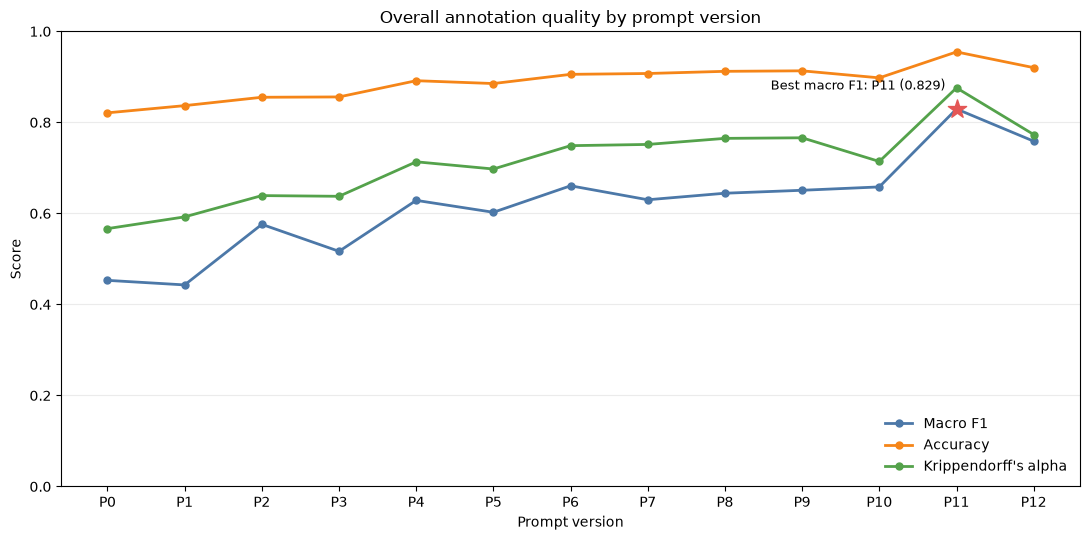

In [19]:
prompt_order = [prompt for prompt in PROMPTS if prompt in scores.index]
prompt_x = list(range(len(prompt_order)))
fig, ax = plt.subplots(figsize=(11, 5.5))
overall_series = {
    'Macro F1': ('macro_f1_P', '#4C78A8'),
    'Accuracy': ('accuracy', '#F58518'),
    "Krippendorff's alpha": ('alpha', '#54A24B'),
}
for label, (column, color) in overall_series.items():
    ax.plot(
        prompt_x, scores.loc[prompt_order, column],
        marker='o', linewidth=2, markersize=5, label=label, color=color,
    )

best_prompt = scores.loc[prompt_order, 'macro_f1_P'].idxmax()
best_x = prompt_order.index(best_prompt)
best_y = scores.loc[best_prompt, 'macro_f1_P']
ax.scatter(best_x, best_y, marker='*', s=190, color='#E45756', zorder=5)
ax.annotate(
    f'Best macro F1: {best_prompt} ({best_y:.3f})',
    (best_x, best_y), xytext=(-8, 14), textcoords='offset points',
    ha='right', fontsize=9,
)

ax.set(
    title='Overall annotation quality by prompt version',
    xlabel='Prompt version', ylabel='Score', ylim=(0, 1),
)
ax.set_xticks(prompt_x, prompt_order)
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

### 8.2 Family-level F1 heatmap

Each cell is the positive-class F1 for one prompt and misconception family. The column labels include the number of positive gold labels, which matters when interpreting unstable scores—especially **principles**, with only four positives.

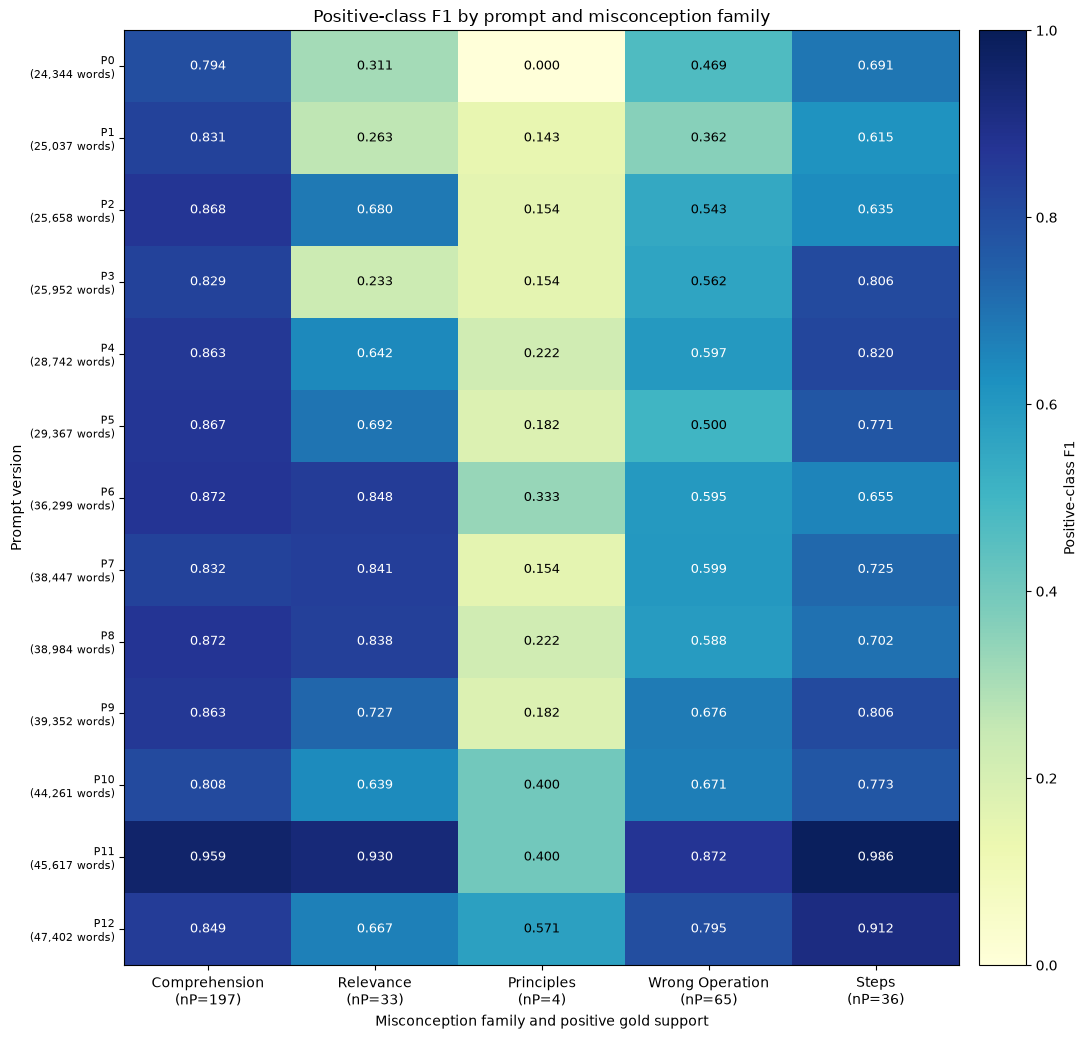

In [20]:
family_support = {
    family: int(gold[family].eq('P').sum())
    for family in scoring.FAMILIES
}
family_matrix = family_f1.loc[prompt_order, scoring.FAMILIES]
family_labels = [
    f"{family.replace('_', ' ').title()}\n(nP={family_support[family]})"
    for family in scoring.FAMILIES
]

heatmap_prompt_labels = [
    f"{prompt}\n({int(scores.loc[prompt, 'prompt_word_count']):,} words)"
    for prompt in prompt_order
]

fig, ax = plt.subplots(figsize=(11.5, 10.5))
heatmap = ax.imshow(
    family_matrix.to_numpy(), aspect='auto', cmap='YlGnBu', vmin=0, vmax=1,
)
ax.set_xticks(range(len(scoring.FAMILIES)), family_labels)
ax.set_yticks(range(len(prompt_order)), heatmap_prompt_labels, fontsize=8)
ax.set_xlabel('Misconception family and positive gold support')
ax.set_ylabel('Prompt version')
ax.set_title('Positive-class F1 by prompt and misconception family')

for row_index in range(len(prompt_order)):
    for column_index in range(len(scoring.FAMILIES)):
        value = family_matrix.iloc[row_index, column_index]
        text_color = 'white' if value >= 0.58 else 'black'
        ax.text(
            column_index, row_index, f'{value:.3f}',
            ha='center', va='center', color=text_color, fontsize=9,
        )

colorbar = fig.colorbar(heatmap, ax=ax, pad=0.02)
colorbar.set_label('Positive-class F1')
plt.tight_layout()
plt.show()

## Notes

- Moonshot reports token usage but not dollar cost, so cost is not included in the result tables.
- Prefix caching is automatic. Repeated prompt prefixes may appear as cached prompt tokens in the response metadata.
- Kimi K3 is stochastic on this backend because its sampling values are fixed server-side.
- The direct backend stops a request after 300 seconds without a new model token and records the failure in its cache.
- `MAX_COMPLETION_TOKENS` defaults to the server allowance. Increase it only when a completion demonstrably runs out of output space.
- Invalid records are retried whenever `RUN_EXTRACTION=True`; set it to `False` for a scoring-only pass.